In [5]:
#import gseapy as gp
import scanpy as sc
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

import re




In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sc.settings.figdir = "fig4"

sc.settings.set_figure_params(dpi_save=300, dpi=50, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
plt.rcParms['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.grid'] = False


AttributeError: module 'matplotlib.pyplot' has no attribute 'rcParms'

## DEGs for sebaceous immune niche


In [ ]:
gene_programme200 = ["CFB", "CCL1", "SFXN1", "EGR2", "SOCS1", "IL2RG", "CXCL16", "SLCO2B1", "CCL17", "ZAP70", "BATF", "IKZF1", "HCK", "TNFRSF12A", "PNP", "SPI1", "PIK3CD", "PDPN", "XDH", "CCL22", 
     "FAS", "TNFRSF10A",  "CD6" , "CA9", "RELT", "LAT", "PTAFR", "TCF7", "CXCL10", "CRB2", "BCAN", "NTRK1", "CXCL9", "CGAS", "CD1A"]
len(gene_programme200)

In [6]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata=sc.read_h5ad(PATH2)
adata=adata[adata.obs["tech"]=="xenium"]

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [1]:
# sc.pl.dotplot(adata, 
#               gene_programme200,
#               groupby="niche19",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=0.3,
#               vmax=1
#                )


In [12]:
adata_i=adata[adata.obs["niche19"].str.startswith("Epi")].copy()

In [13]:
CATEGORY="niche19"
sc.tl.rank_genes_groups(adata_i, CATEGORY, method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(adata_i.uns['de_leiden']['names'])
#df2.to_pickle("degs_niche.pkl")


Epidermis_APChi


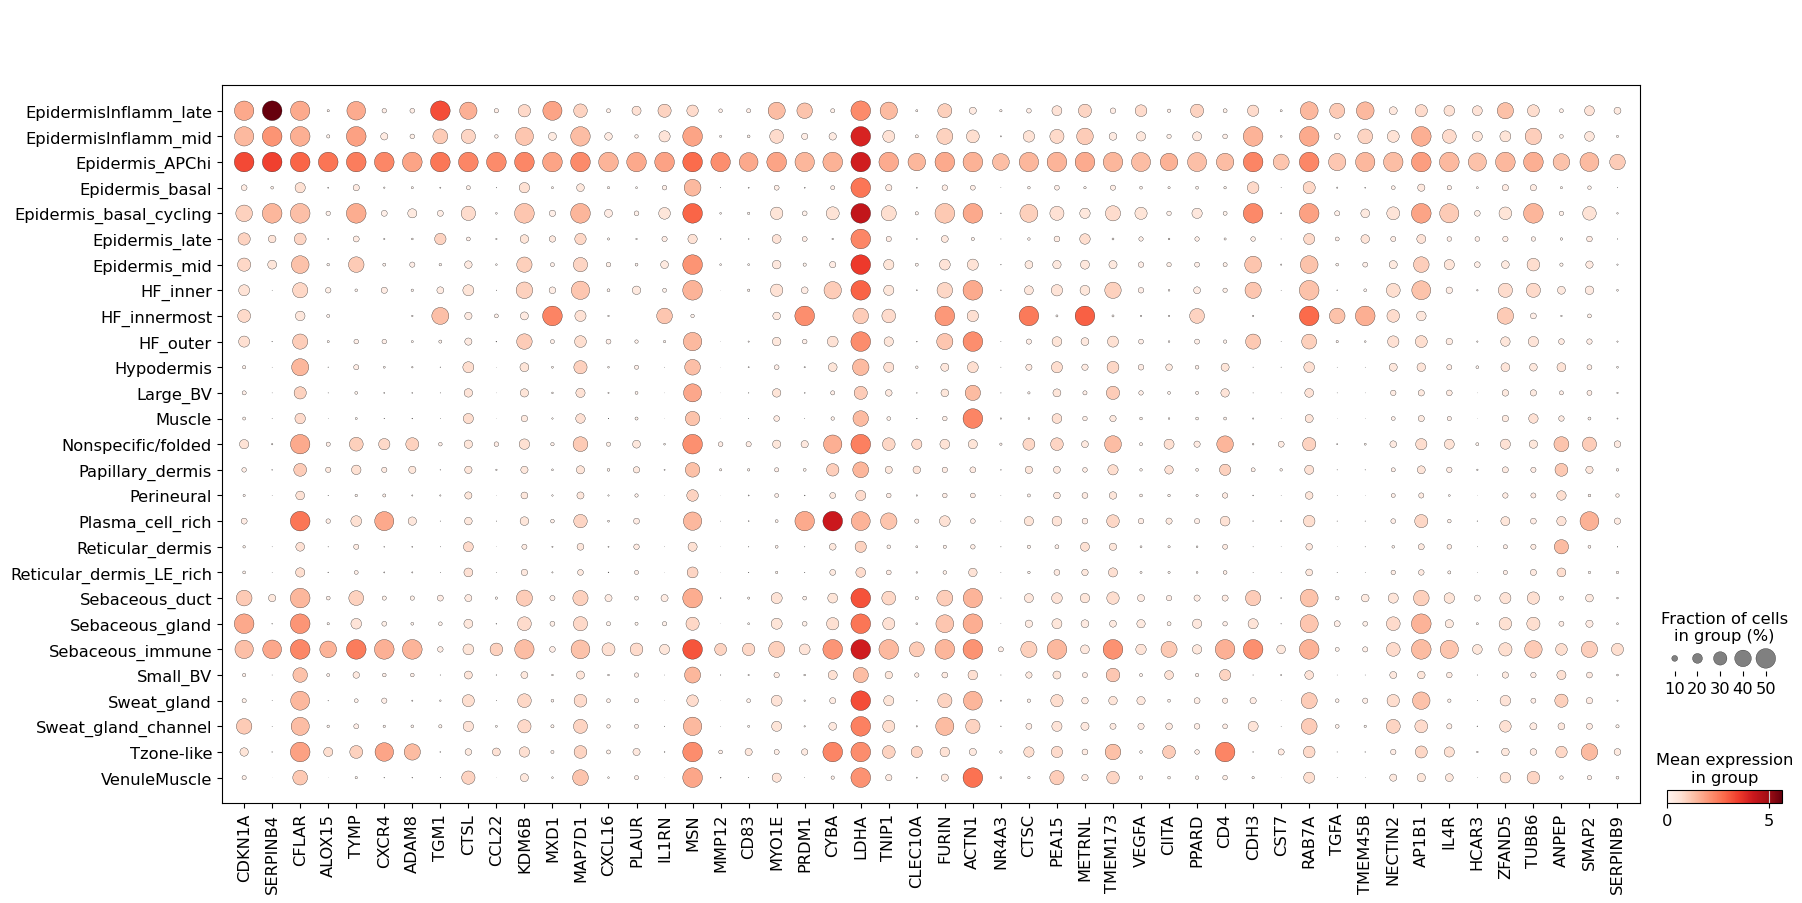

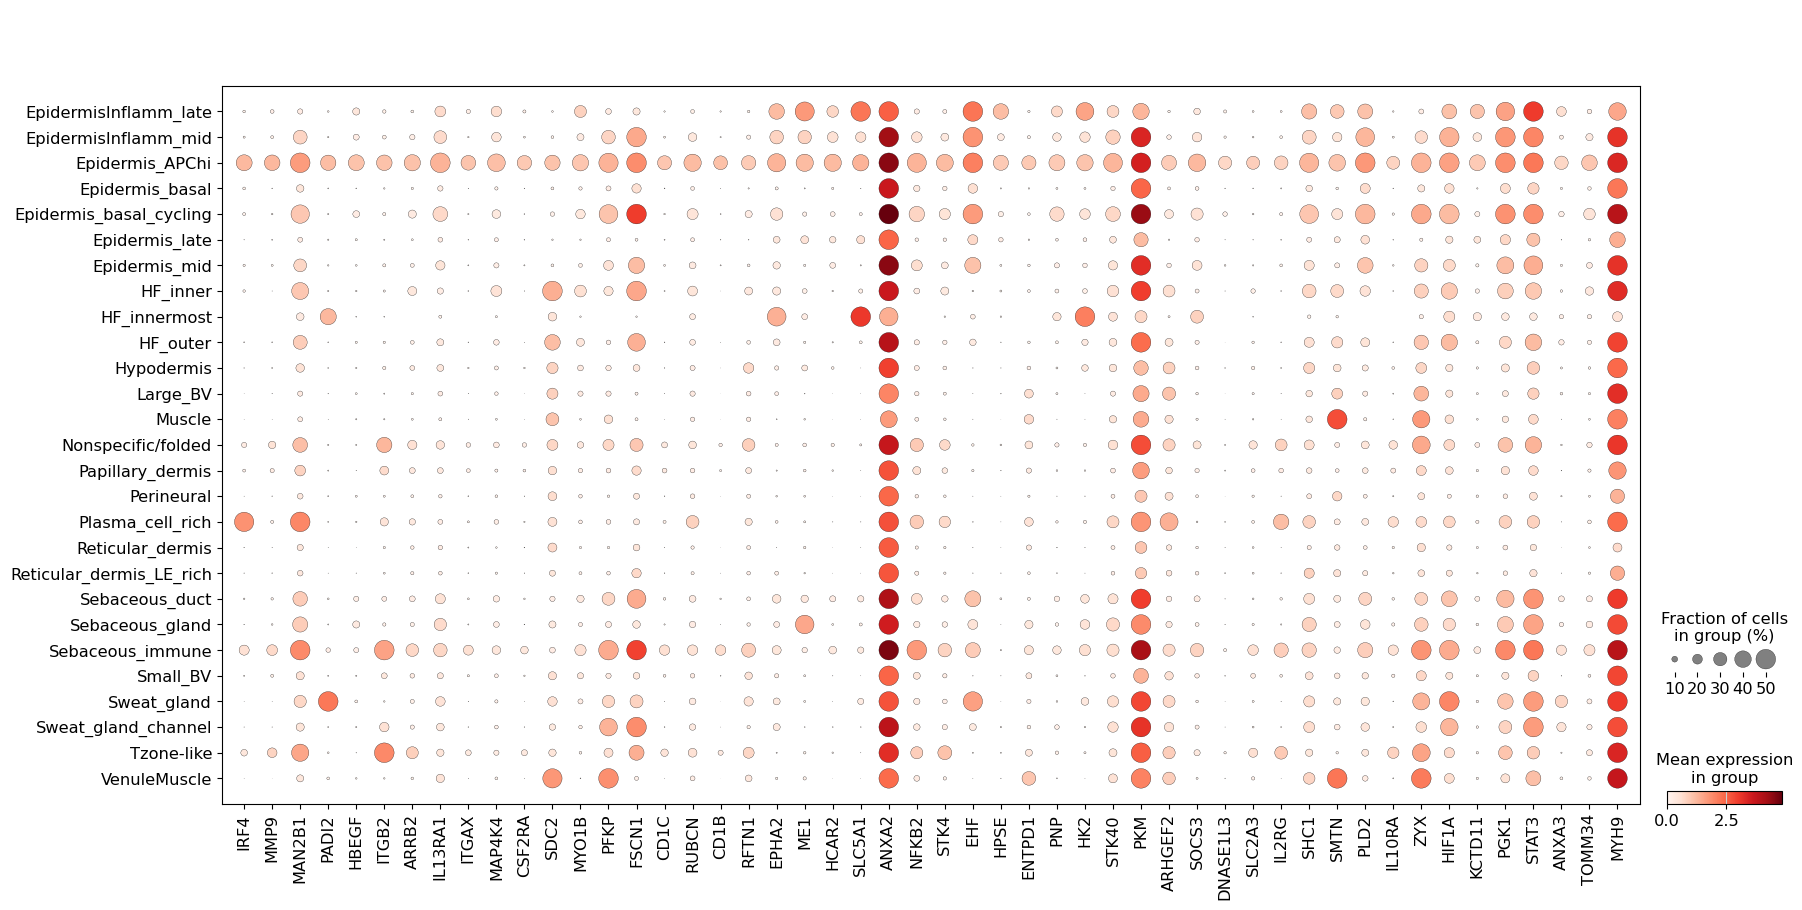

In [14]:
select_population = list(df2.columns)[2]  # JAW
print(select_population)
genes0 = df2[select_population][:50]
genes1 = df2[select_population][50:100]
genes2 = df2[select_population][100:150]
genes3 = df2[select_population][150:200]

CATEGORY="niche19"
sc.pl.dotplot(
    adata,
    genes0,
    groupby=CATEGORY,
    #standard_scale="var",
    dendrogram=False, 
    dot_max=0.5,
)
sc.pl.dotplot(
    adata,
    genes1,
    groupby=CATEGORY,
   # standard_scale="var",
    dendrogram=False, 
        dot_max=0.5,

) 



In [18]:
gene_list = df2[select_population][:100]
list(gene_list)

['CDKN1A',
 'SERPINB4',
 'CFLAR',
 'ALOX15',
 'TYMP',
 'CXCR4',
 'ADAM8',
 'TGM1',
 'CTSL',
 'CCL22',
 'KDM6B',
 'MXD1',
 'MAP7D1',
 'CXCL16',
 'PLAUR',
 'IL1RN',
 'MSN',
 'MMP12',
 'CD83',
 'MYO1E',
 'PRDM1',
 'CYBA',
 'LDHA',
 'TNIP1',
 'CLEC10A',
 'FURIN',
 'ACTN1',
 'NR4A3',
 'CTSC',
 'PEA15',
 'METRNL',
 'TMEM173',
 'VEGFA',
 'CIITA',
 'PPARD',
 'CD4',
 'CDH3',
 'CST7',
 'RAB7A',
 'TGFA',
 'TMEM45B',
 'NECTIN2',
 'AP1B1',
 'IL4R',
 'HCAR3',
 'ZFAND5',
 'TUBB6',
 'ANPEP',
 'SMAP2',
 'SERPINB9',
 'IRF4',
 'MMP9',
 'MAN2B1',
 'PADI2',
 'HBEGF',
 'ITGB2',
 'ARRB2',
 'IL13RA1',
 'ITGAX',
 'MAP4K4',
 'CSF2RA',
 'SDC2',
 'MYO1B',
 'PFKP',
 'FSCN1',
 'CD1C',
 'RUBCN',
 'CD1B',
 'RFTN1',
 'EPHA2',
 'ME1',
 'HCAR2',
 'SLC5A1',
 'ANXA2',
 'NFKB2',
 'STK4',
 'EHF',
 'HPSE',
 'ENTPD1',
 'PNP',
 'HK2',
 'STK40',
 'PKM',
 'ARHGEF2',
 'SOCS3',
 'DNASE1L3',
 'SLC2A3',
 'IL2RG',
 'SHC1',
 'SMTN',
 'PLD2',
 'IL10RA',
 'ZYX',
 'HIF1A',
 'KCTD11',
 'PGK1',
 'STAT3',
 'ANXA3',
 'TOMM34',
 'MYH9']

In [1]:
import gseapy as gp
import scanpy as sc
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

import re




In [2]:
gene_list=['CDKN1A',
 'SERPINB4',
 'CFLAR',
 'ALOX15',
 'TYMP',
 'CXCR4',
 'ADAM8',
 'TGM1',
 'CTSL',
 'CCL22',
 'KDM6B',
 'MXD1',
 'MAP7D1',
 'CXCL16',
 'PLAUR',
 'IL1RN',
 'MSN',
 'MMP12',
 'CD83',
 'MYO1E',
 'PRDM1',
 'CYBA',
 'LDHA',
 'TNIP1',
 'CLEC10A',
 'FURIN',
 'ACTN1',
 'NR4A3',
 'CTSC',
 'PEA15',
 'METRNL',
 'TMEM173',
 'VEGFA',
 'CIITA',
 'PPARD',
 'CD4',
 'CDH3',
 'CST7',
 'RAB7A',
 'TGFA',
 'TMEM45B',
 'NECTIN2',
 'AP1B1',
 'IL4R',
 'HCAR3',
 'ZFAND5',
 'TUBB6',
 'ANPEP',
 'SMAP2',
 'SERPINB9',
 'IRF4',
 'MMP9',
 'MAN2B1',
 'PADI2',
 'HBEGF',
 'ITGB2',
 'ARRB2',
 'IL13RA1',
 'ITGAX',
 'MAP4K4',
 'CSF2RA',
 'SDC2',
 'MYO1B',
 'PFKP',
 'FSCN1',
 'CD1C',
 'RUBCN',
 'CD1B',
 'RFTN1',
 'EPHA2',
 'ME1',
 'HCAR2',
 'SLC5A1',
 'ANXA2',
 'NFKB2',
 'STK4',
 'EHF',
 'HPSE',
 'ENTPD1',
 'PNP',
 'HK2',
 'STK40',
 'PKM',
 'ARHGEF2',
 'SOCS3',
 'DNASE1L3',
 'SLC2A3',
 'IL2RG',
 'SHC1',
 'SMTN',
 'PLD2',
 'IL10RA',
 'ZYX',
 'HIF1A',
 'KCTD11',
 'PGK1',
 'STAT3',
 'ANXA3',
 'TOMM34',
 'MYH9']

In [3]:
gsea_results = []

enr = gp.enrichr(gene_list=gene_list[:100],
                 gene_sets='GO_Biological_Process_2023',   
                 outdir=None,  
                 cutoff=0.05  # Cutoff for statistical significance
                )
#enr.results['Cluster'] = cluster
gsea_results.append(enr.results)

gsea_df = pd.concat(gsea_results)



/tmp/ipykernel_1183398/4151146917.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


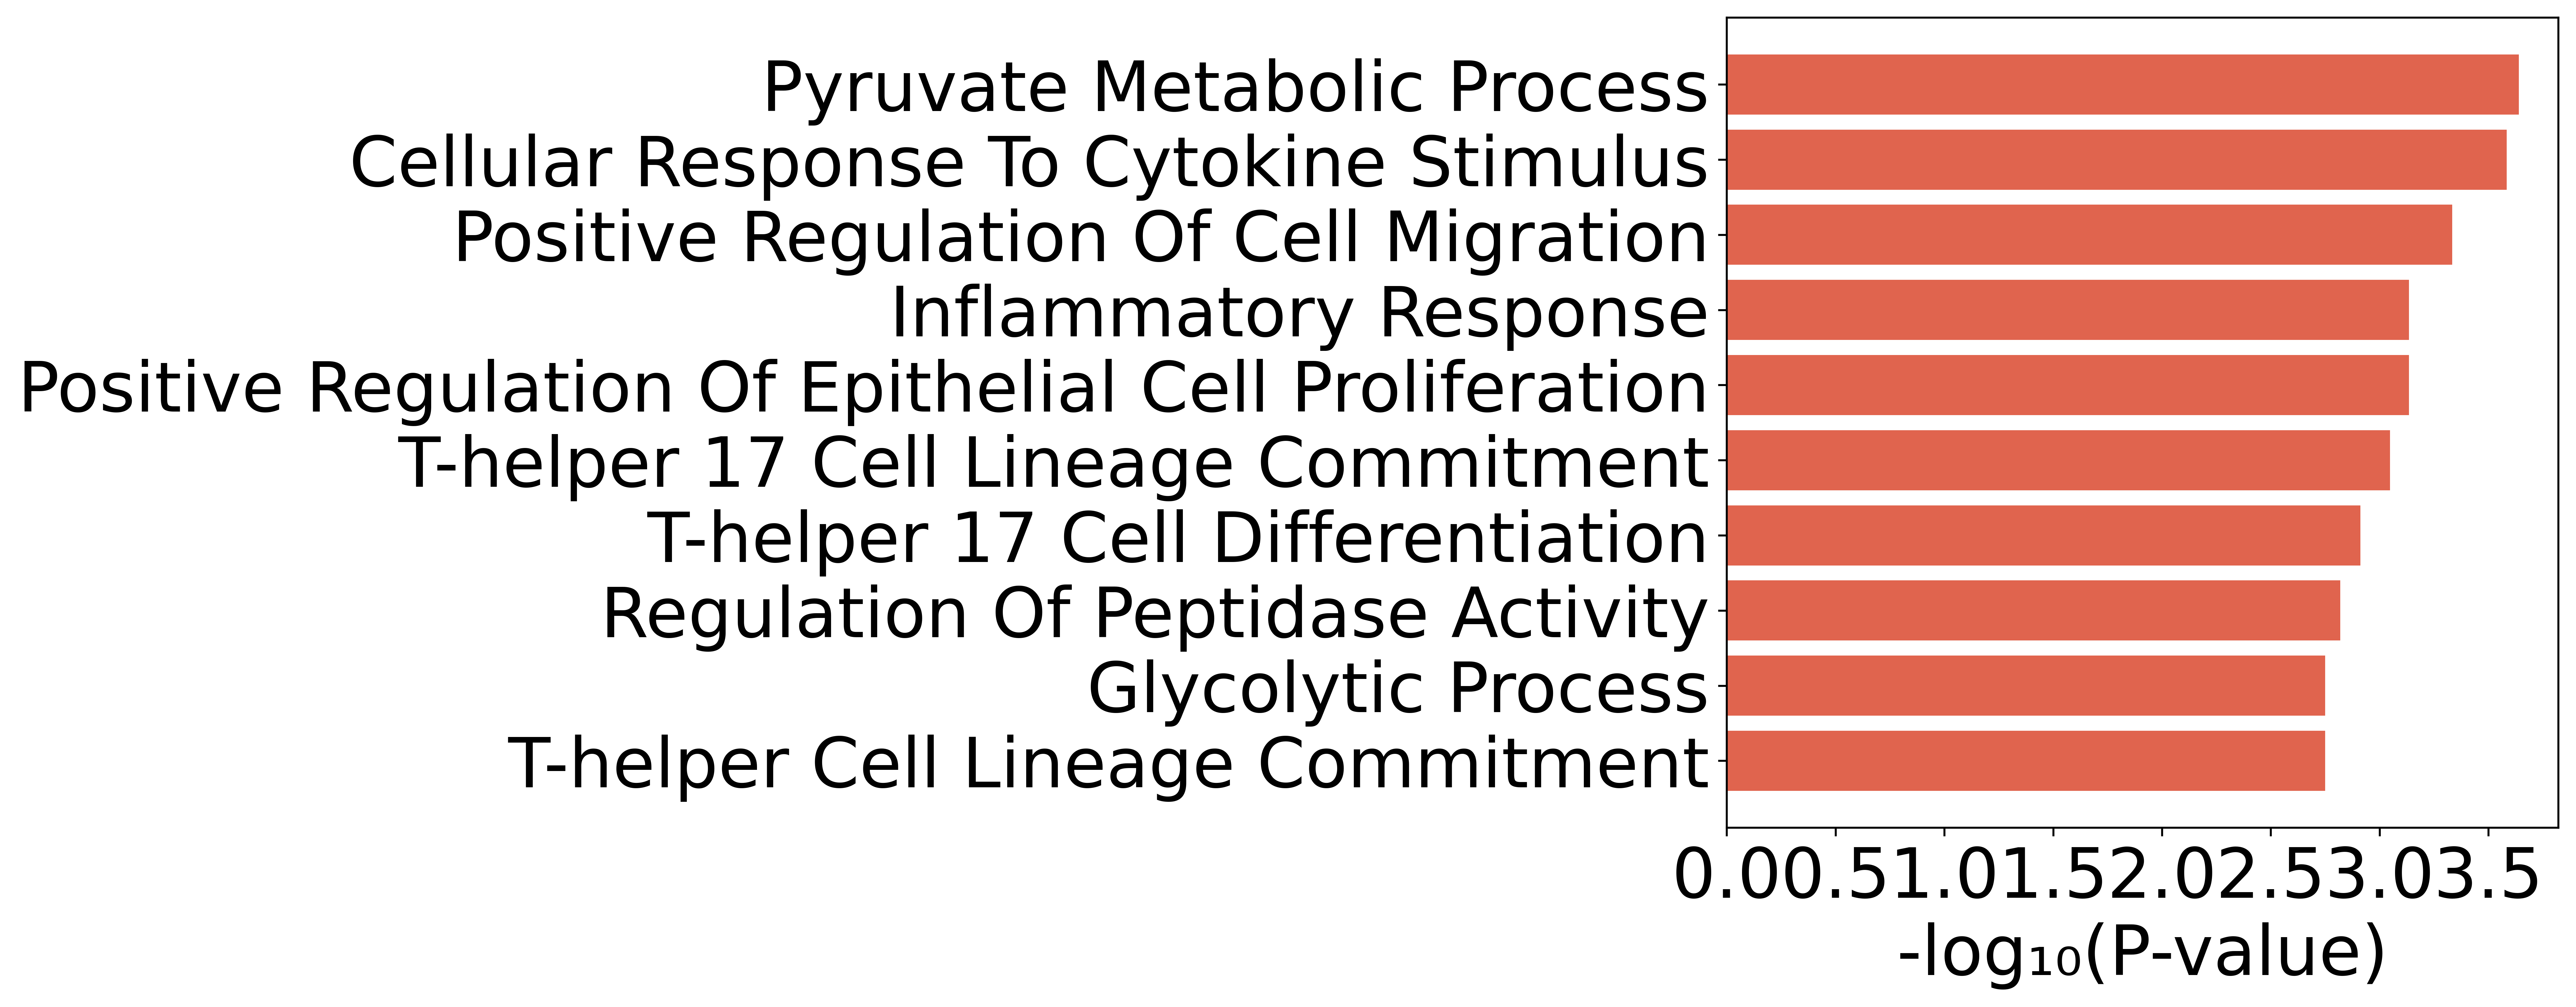

In [5]:
top_n = 10  # adjust as needed
gsea_df_sorted = gsea_df.sort_values(by='Adjusted P-value').head(top_n)

# Calculate -log10(padj)
gsea_df_sorted['-log10(padj)'] = gsea_df_sorted['Adjusted P-value'].apply(
    lambda p: -1 if p <= 0 else -np.log10(p)  # NOTE the negative sign here!
)

# Sort so most significant (highest -log10) are at top
gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=False)

sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.grid'] = False

#sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)

gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

plt.figure(figsize=(6, 6))
plt.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#e0644e'
)
plt.xlabel('-log₁₀(P-value)', fontsize=28)
plt.yticks(fontsize=28)  
plt.xticks(fontsize=28)  


plt.ylabel('')
plt.tight_layout()
#plt.savefig('gsea_sebimmune_small2.pdf', dpi=300)
#plt.savefig("fig4/4g_gsea_apchi.pdf", dpi=300, bbox_inches='tight')

plt.show()



/tmp/ipykernel_3036658/2048247651.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


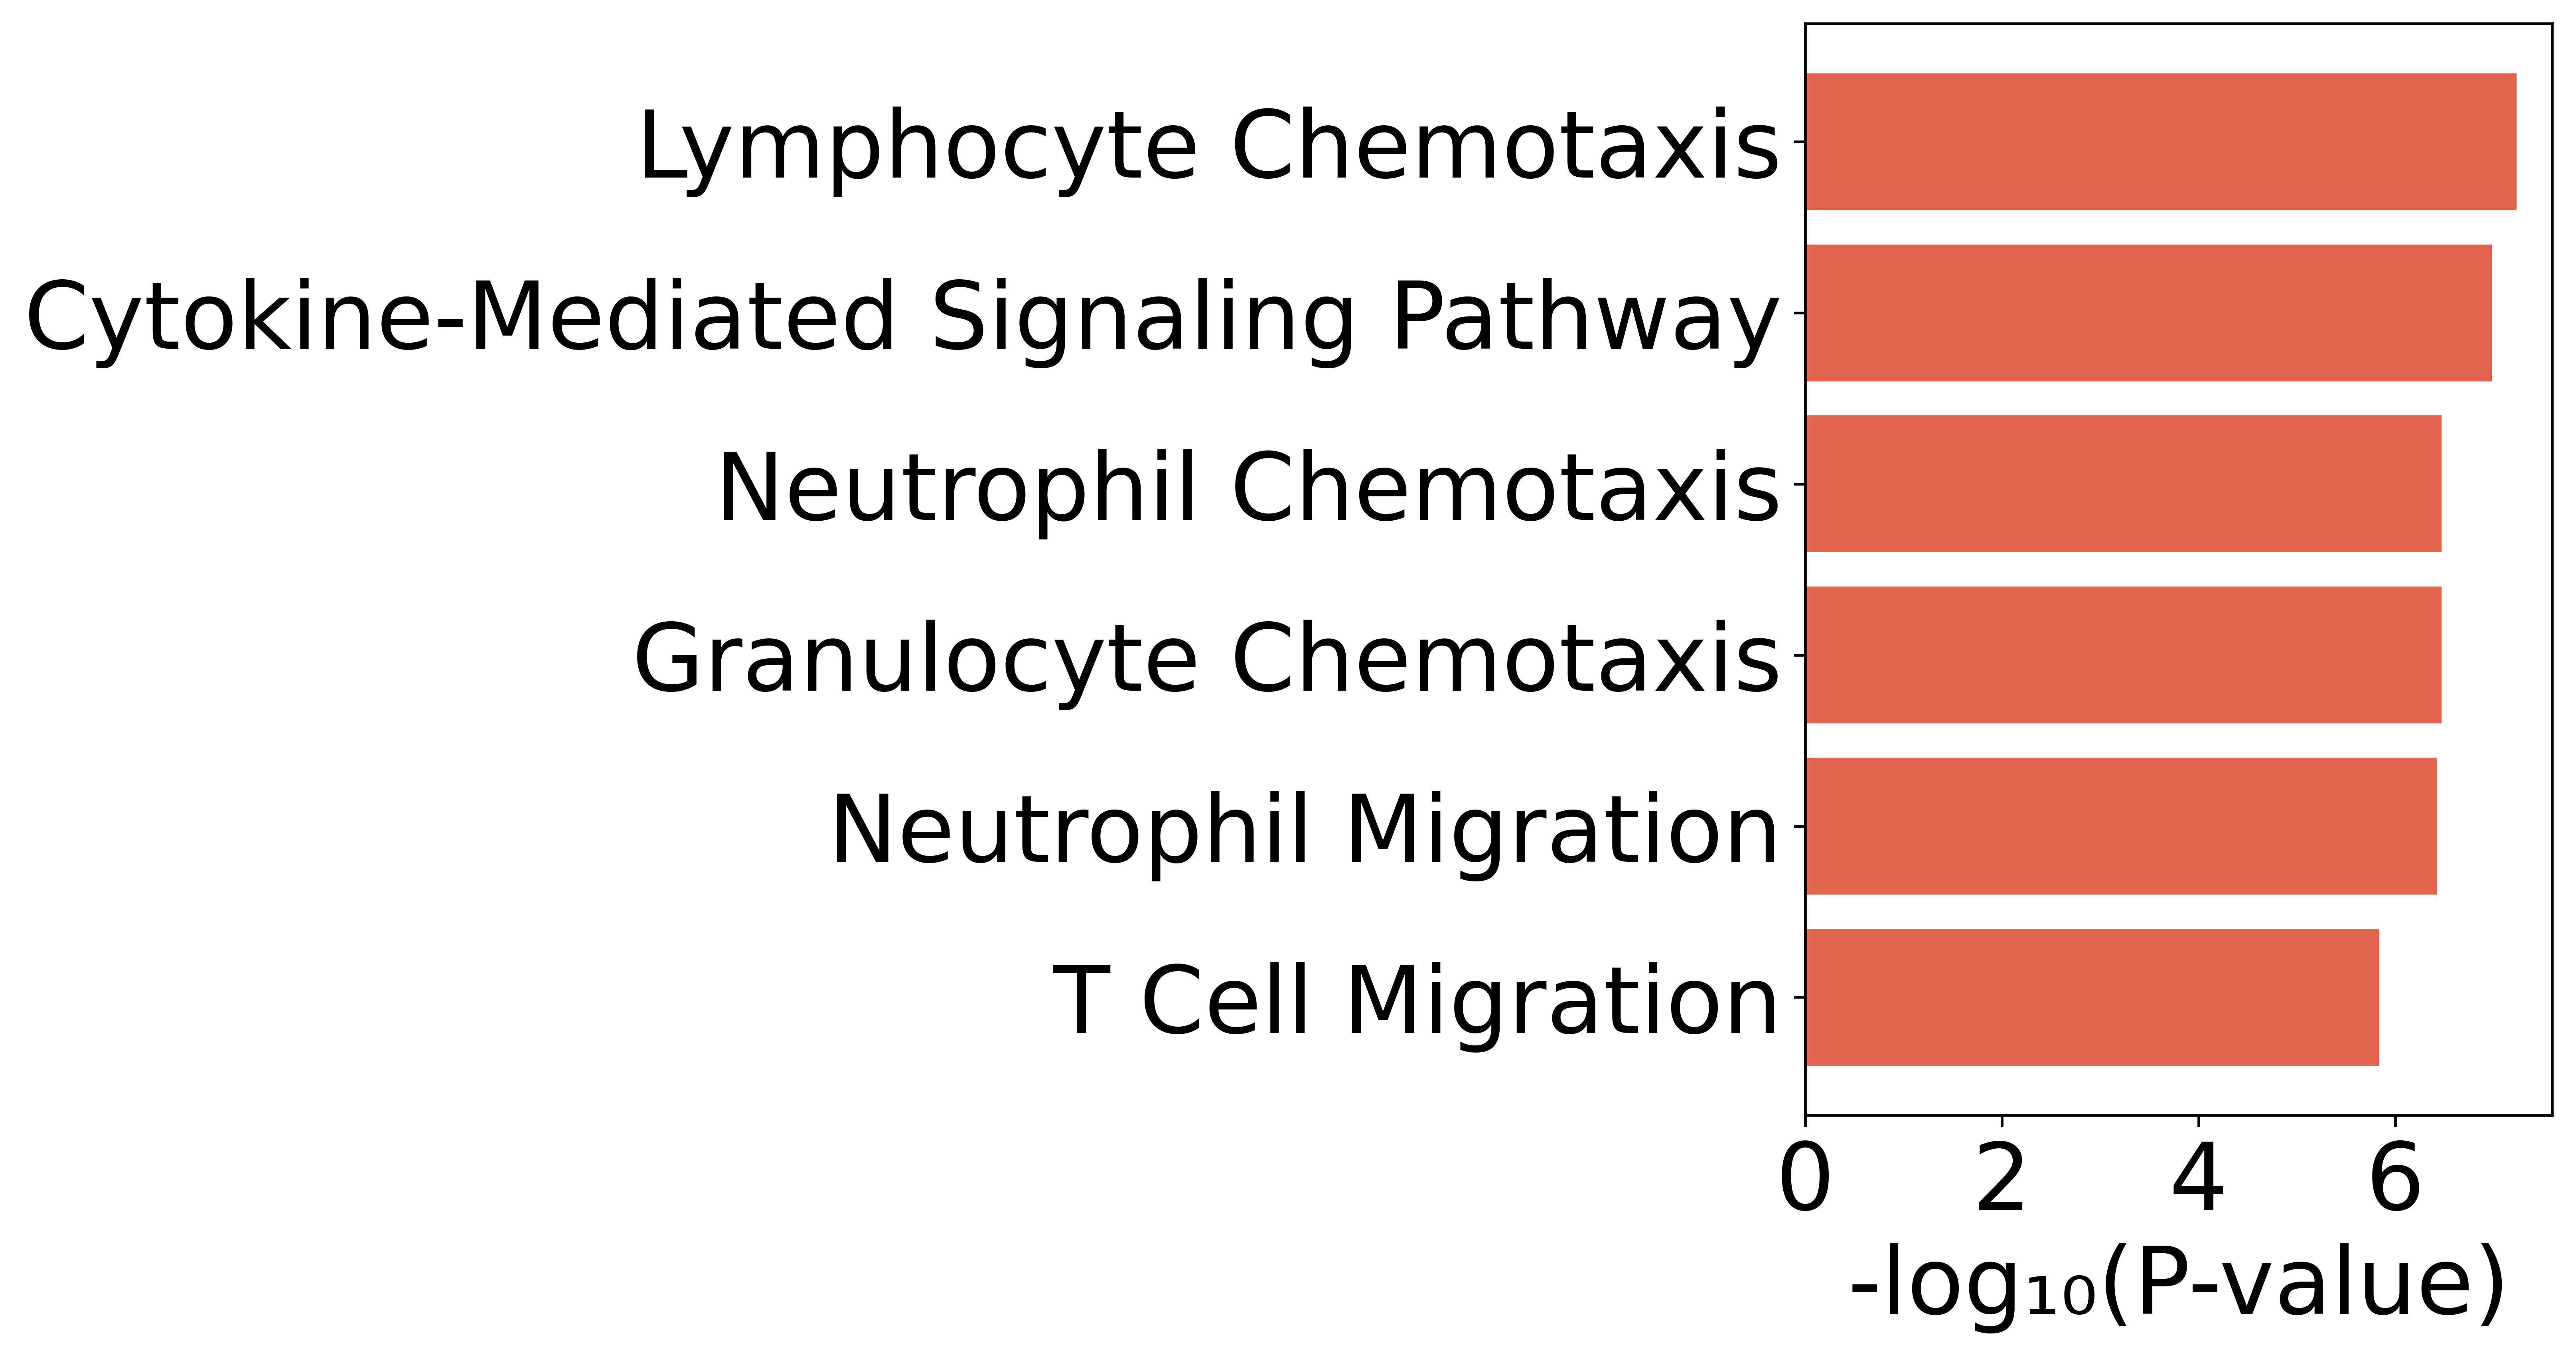

In [10]:
sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.grid'] = False

#sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(5,5))# grid=False)
gsea_df_sorted = gsea_df_sorted.sort_values(by='-log10(padj)', ascending=True)

gsea_df_sorted['Term_clean'] = gsea_df_sorted['Term'].str.replace(
    r'\s*\(.*\)$', '', regex=True
)

plt.figure(figsize=(4, 6))
plt.barh(
    y=gsea_df_sorted['Term_clean'],
    width=gsea_df_sorted['-log10(padj)'],
    color='#e0644e'
)
plt.xlabel('-log₁₀(P-value)', fontsize=28)
plt.yticks(fontsize=28)  
plt.xticks(fontsize=28)  


plt.ylabel('')
plt.tight_layout()
plt.savefig('fig4/fig4_gsea_sebimmune_small.pdf', dpi=300)
plt.show()

